# <center>🏡House Price Prediction🏠 </center>

# Problem Statement:
 Real estate buyers and sellers often rely on guesswork or outdated comparisons to estimate a property's fair value. Your task is to build a regression model that predicts house prices based on property features such as size, number of rooms, location, and age and then identify which features most strongly influence price.

# Step 1: Importing Essential Libraries, Metrics, Tools & Models

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Step 2: Loading The Data

In [2]:
df= pd.read_csv('Housing.csv')

# Step 3: Data Exploration

### Taking a look at the first 10 rows of the dataset

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Checking the shape i.e., size of the data

In [4]:
df.shape

(545, 13)

### Learning the data-types of columns and how many non-null values there are in those columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### Getting the statistical summary of the dataset

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Target Variable

In [7]:
target = "price"

print("Target Variable:")
print(target)

print("\nFeature Variables:")
print(df.drop(columns=[target]).columns)

Target Variable:
price

Feature Variables:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


# Step 4: Data Cleaning

### Handling Missing Values

In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

#### It seems that there is no duplicates in the dataset

In [9]:
df.duplicated().sum()

0

### Remove duplicate rows

In [10]:
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(545, 13)


### To check the data type of each column inside a DataFrame

In [11]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

### Display unique values

In [12]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


### Binary Encoding

In [13]:
binary_columns = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

for col in binary_columns:
    df[col] = df[col].map({'yes': 1,'no': 0})

In [14]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


## One-hot encoding

In [15]:
df = pd.get_dummies(df,columns=['furnishingstatus'], drop_first=True)

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [17]:
df.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

In [18]:
df.shape

(545, 14)

# Step 5: Model Building & Evaluation

### Defining X , y

In [19]:
X = df.drop("price", axis=1)
y = df["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


In [20]:
print("Feature Columns:")
X.columns

Feature Columns:


Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

### Split the data into training and test

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [22]:
X_train.shape,y_train.shape

((436, 13), (436,))

In [23]:
X_test.shape, y_test.shape

((109, 13), (109,))

## Train the Linear Regression Model:

In [24]:
# Initialise and train
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# Predictions
y_pred_lin = lin_model.predict(X_test)

## Model Evaluation

In [26]:
# Evaluation Metrics
print("\nLinear Regression Metrics:")

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print(f"MAE: {mae_lin:.2f}")
print(f"RMSE: {rmse_lin:.2f}")
print(f"R² Score: {r2_lin:.2f}")


Linear Regression Metrics:
MAE: 970043.40
RMSE: 1324506.96
R² Score: 0.65


## Train the Random Forest Regression Model:

In [27]:
# Initialise and train
rf_model = RandomForestRegressor(n_estimators=200,random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

## Model Evaluation

In [29]:
# Evaluation Metrics
print("\nRandom Forest Regression Metrics:")

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.2f}")


Random Forest Regression Metrics:
MAE: 1014947.32
RMSE: 1399769.44
R² Score: 0.61


## Step 6: Comparing Both the Models:

In [30]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lin, mae_rf],
    "RMSE": [rmse_lin, rmse_rf],
    "R² Score": [r2_lin, r2_rf]})

comparison.round(2)

,Model,MAE,RMSE,R² Score
0,Linear Regression,970043.40,1324506.96,0.65
1,Random Forest,1014947.32,1399769.44,0.61


## Best Model 

In [31]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]

print("Best Model")
print("-" * 30)

print(best_model)

Best Model
------------------------------
Model       Linear Regression
MAE              970043.40392
RMSE           1324506.960091
R² Score             0.652924
Name: 0, dtype: object


# Step 7: Feature Importance

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,area,0.467809
2,bathrooms,0.152635
8,airconditioning,0.060260
9,parking,0.057557
3,stories,0.057045
1,bedrooms,0.047544
12,furnishingstatus_unfurnished,0.036974
6,basement,0.032418
10,prefarea,0.028316
7,hotwaterheating,0.018333


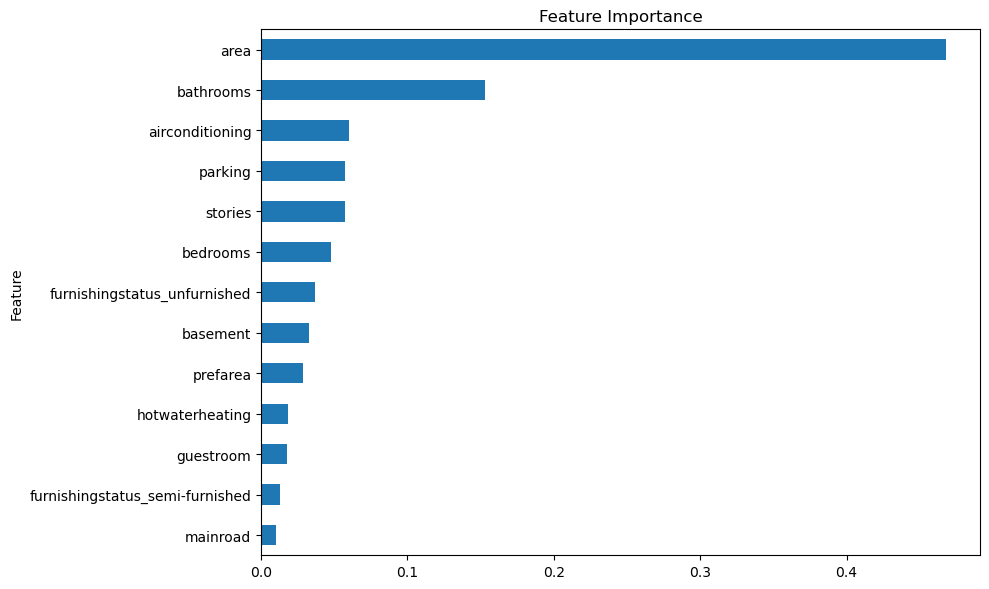

In [33]:
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": rf_model.feature_importances_})
feature_importance.sort_values(by="Importance",ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
feature_importance.sort_values(by="Importance", ascending=True).plot(x="Feature", y="Importance", kind="barh", legend=False, ax=ax)

ax.set_title("Feature Importance")
plt.tight_layout()
plt.show()

# Step 8: Model Visualization

## Histogram

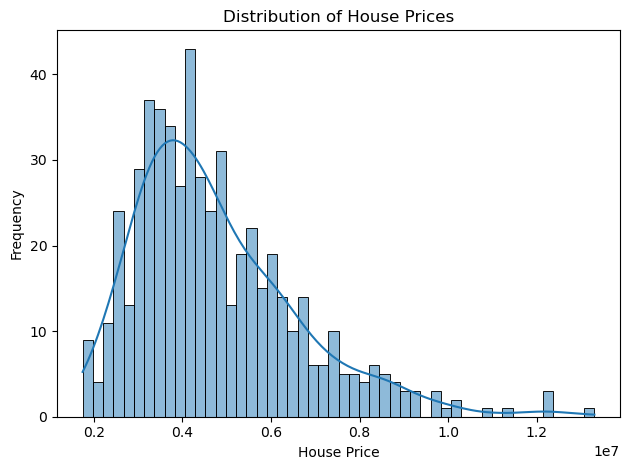

In [34]:
plt.figure()
sns.histplot(df['price'], bins=50, kde= True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Correlation Heatmap

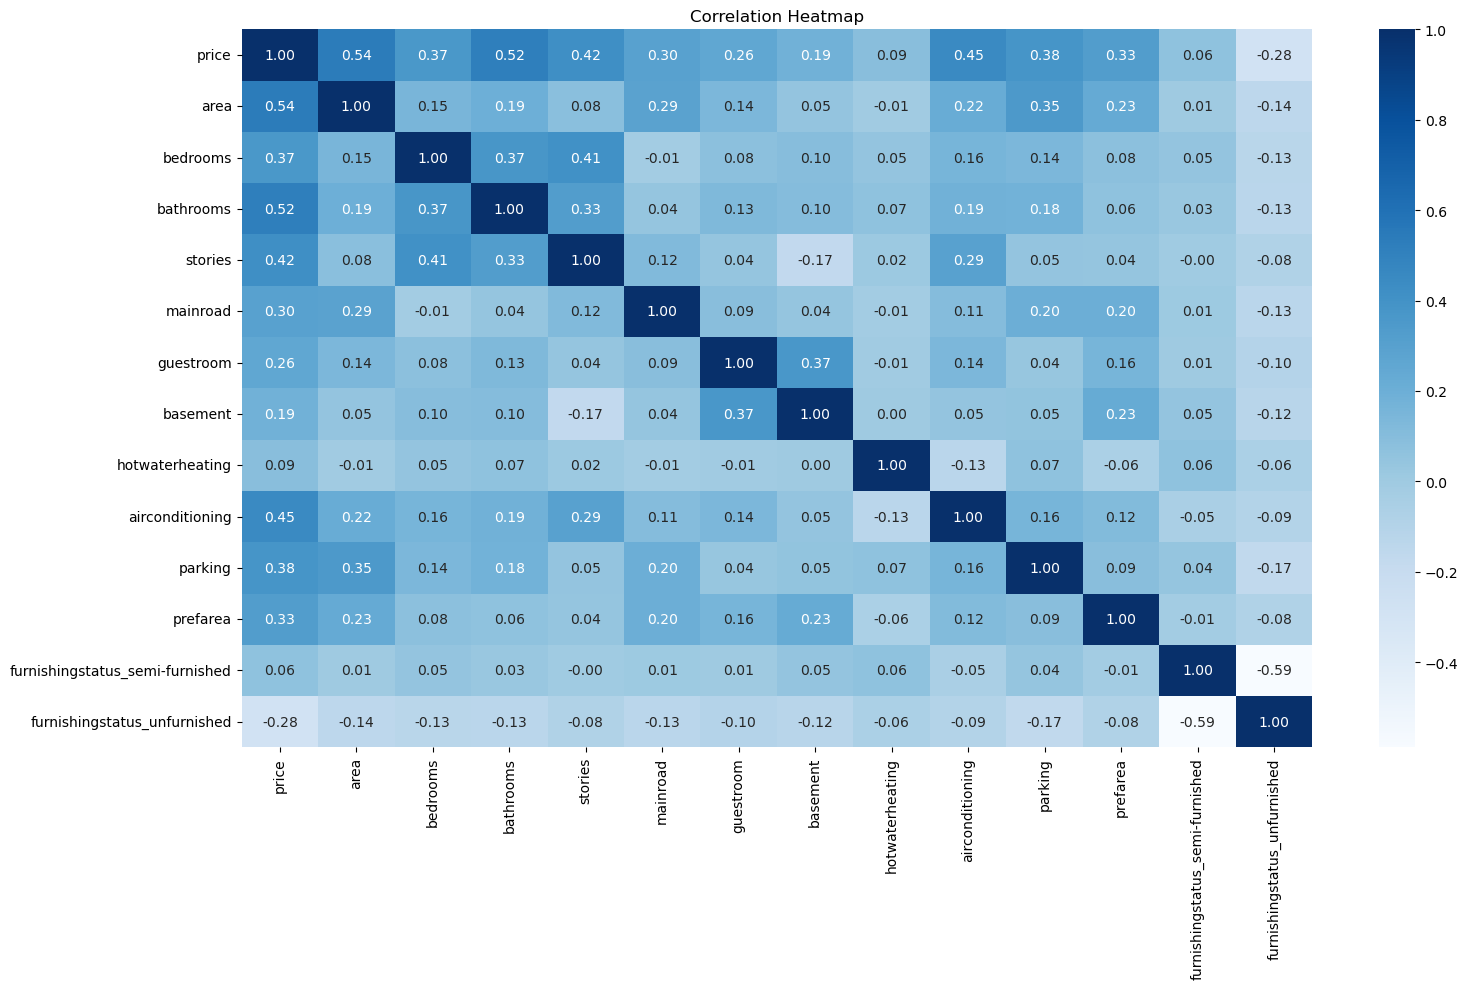

In [35]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(),annot=True,cmap="Blues",fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Actual vs Predicted Scatter Plot

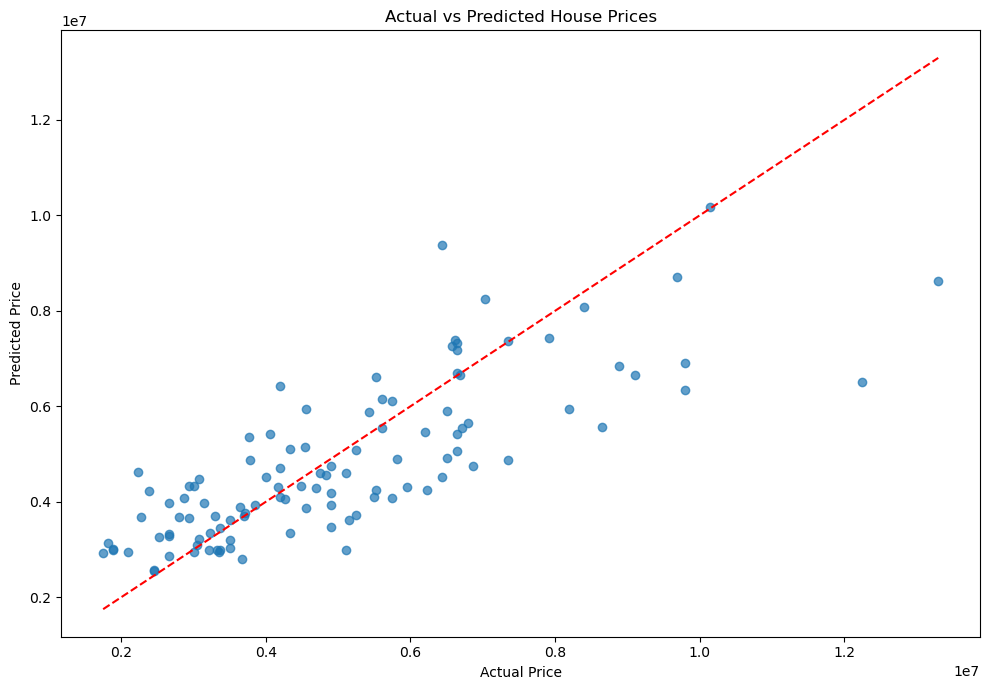

In [36]:
plt.figure(figsize=(10,7))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

# Step 9: Insights & Summary

The analysis showed that area, bathrooms, air conditioning, stories, and parking availability were among the most influential features affecting house prices. Larger houses with more bathrooms and modern amenities generally had higher market values.

Among the two models tested, the Linear Regression model achieved better performance than the Random Forest Regressor, with a higher R² score (0.65 vs 0.61) and lower MAE and RMSE. This suggests that, on this dataset, price has a fairly strong linear relationship with the features, so the added complexity of Random Forest didn't translate into better predictions.

One interesting observation from the dataset was that certain amenities, such as air conditioning and being located in a preferred area, had a noticeable impact on house prices, while features like bedrooms and mainroad access had a weaker influence than expected.

Based on these findings, a real estate business should focus on properties with larger living areas, sufficient parking, multiple bathrooms, and modern amenities when estimating property values or developing pricing strategies. Given that a simple Linear Regression model performed competitively here, it could be used as a fast, interpretable baseline for price estimation, with more complex models reserved for larger or more nonlinear datasets.

# Step 10: Conclusion

Linear Regression achieved the best performance on this dataset and is recommended for predicting house prices, as it produced the lowest prediction error (MAE and RMSE) and the highest R² score compared to Random Forest. This indicates the relationship between the chosen features and price is largely linear, making a simpler, more interpretable model the better practical choice here.